In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_clean = pd.read_csv("../../data/processed/df_clean.csv")

In [3]:
df_prepare_clustering = df_clean.copy()

In [4]:
df_prepare_clustering.head()

,BALANCE,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS
0,40.900749,95.40,0.00,95.4,0.000000,1000.0,201.802084
1,3202.467416,0.00,0.00,0.0,6442.945483,7000.0,4103.032597
2,2495.148862,773.17,773.17,0.0,0.000000,7500.0,622.066742
3,1666.670542,1499.00,1499.00,0.0,205.788017,7500.0,0.000000
4,817.714335,16.00,16.00,0.0,0.000000,1200.0,678.334763


In [5]:
targeted_cols = ["BALANCE","PURCHASES","ONEOFF_PURCHASES",
        "INSTALLMENTS_PURCHASES","CASH_ADVANCE","CREDIT_LIMIT","PAYMENTS"]

In [6]:
skew_before = df_prepare_clustering[targeted_cols].skew()

In [7]:
df_prepare_clustering[targeted_cols] = np.log1p(df_prepare_clustering[targeted_cols])

In [8]:
skew_after = df_prepare_clustering[targeted_cols].skew()

In [9]:
pd.DataFrame({"before": skew_before, "after": skew_after}).round(3)

,before,after
BALANCE,2.393,-0.861
PURCHASES,8.144,-0.765
ONEOFF_PURCHASES,10.045,0.186
INSTALLMENTS_PURCHASES,7.299,-0.025
CASH_ADVANCE,5.166,0.263
CREDIT_LIMIT,1.522,-0.101
PAYMENTS,5.907,-1.779


In [10]:
scaler = StandardScaler()
scaled = scaler.fit_transform(df_prepare_clustering)
print(scaled.shape)
print(scaled.mean(axis=0))
print(scaled.std(axis=0))


(8949, 7)
[ 1.27038594e-16  6.35192970e-17 -7.62231564e-17  4.12875430e-17
  2.54077188e-17  3.55708063e-16 -2.54077188e-17]
[1. 1. 1. 1. 1. 1. 1.]


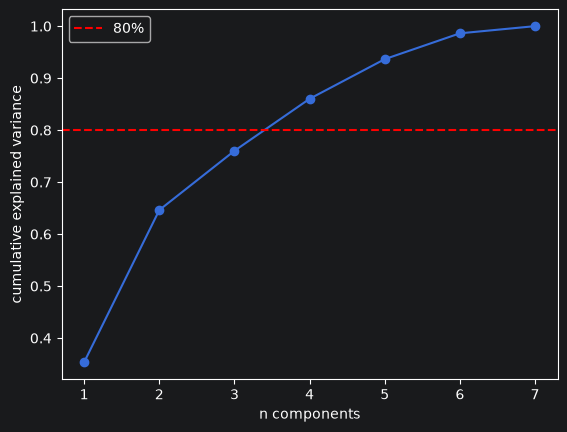

min components for 80%: 4


In [11]:
pca = PCA().fit(scaled)
cum = pca.explained_variance_ratio_.cumsum()
n_80 = int((cum >= 0.8).argmax()) + 1

plt.plot(np.arange(1, scaled.shape[1] + 1), cum, "o-")
plt.axhline(0.8, color="r", linestyle="--", label="80%")
plt.xlabel("n components")
plt.ylabel("cumulative explained variance")
plt.legend()
plt.show()

print(f"min components for 80%: {n_80}")
